# GEA Region NPV Analysis — 2035 Wholesale Prices

Runs ProFAST once per GEA grid region using the 2035 High-Demand hourly wholesale price series (8760 h).  
LCOE is computed first (cost-only baseline), then NPV is evaluated at each region's annual mean wholesale price.

## 1. Imports & Model Setup

In [29]:
import sys
sys.path.insert(0, '/Users/svijaysh/NPP+DCfork/H2Integrate')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from h2integrate.core.h2integrate_model import H2IntegrateModel
from IPython.display import IFrame, display

try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY = True
    print('Plotly available')
except ImportError:
    PLOTLY = False
    print('Plotly not found — static plots only. pip install plotly')

Plotly available


In [30]:
h2i = H2IntegrateModel("examples/32_nuclear_DC_case_1/nuclear_datacenter_config.yaml")
h2i.setup()

def get(path, units=None):
    v = h2i.prob.get_val(path, units=units) if units else h2i.prob.get_val(path)
    return float(v.flat[0]) if hasattr(v, 'flat') else float(v)

print('Model ready.')

Model ready.


## 2. 2035 GEA Wholesale Price Data (8760 h)

In [31]:
import json

with open('2035HighDemand-yearhour-gea.json') as f:
    _gea = json.load(f)

# 8760 hourly wholesale prices in $/MWh, keyed by GEA region name
gea_prices_mwh = {k: np.array(v) for k, v in _gea.items() if k != 'timesteps'}

print(f'{len(gea_prices_mwh)} GEA regions loaded')
for region, prices in sorted(gea_prices_mwh.items(), key=lambda x: -x[1].mean()):
    print(f'  {region:<24}  mean={prices.mean():>7.1f}  min={prices.min():>7.1f}  max={prices.max():>7.1f}  $/MWh')

18 GEA regions loaded
  CAISO                     mean=   56.5  min=   12.0  max= 1684.2  $/MWh
  FRCC                      mean=   55.6  min=   28.4  max= 1456.8  $/MWh
  SERTP                     mean=   54.0  min=   27.3  max= 1283.9  $/MWh
  NYISO                     mean=   53.1  min=   33.3  max=  292.3  $/MWh
  PJM East                  mean=   52.3  min=   25.9  max=  909.0  $/MWh
  PJM West                  mean=   48.7  min=   14.7  max=  689.3  $/MWh
  MISO South                mean=   47.9  min=   24.3  max=  565.4  $/MWh
  MISO Central              mean=   46.5  min=   21.8  max=  560.3  $/MWh
  MISO North                mean=   44.7  min=   15.1  max=  330.3  $/MWh
  Northern Grid South       mean=   44.4  min=   10.8  max= 1060.7  $/MWh
  West Connect South        mean=   43.4  min=   11.1  max= 1113.3  $/MWh
  ERCOT                     mean=   42.5  min=   13.8  max= 1166.7  $/MWh
  ISONE                     mean=   39.0  min=   18.8  max=  311.5  $/MWh
  Northern Grid 

In [32]:
PLANT_MW   = 1000 # 1000 mw plant
capacity_kw = PLANT_MW * 1000 # in kw

h2i.prob.set_val('nuclear.system_capacity',    capacity_kw,                units='kW')
h2i.prob.set_val('grid.interconnection_size',  capacity_kw,                units='kW')
h2i.prob.set_val('nuclear.electricity_command_value', np.full(8760, capacity_kw), units='kW')
h2i.prob.set_val('grid.electricity_command_value',    np.full(8760, 500_000),     units='kW') # Half the demand
h2i.prob.set_val('finance_subgroup_nuclear_npv.sell_price_electricity', 0.12, units='USD/(kW*h)')

h2i.run()

LCOE_MWH   = get('finance_subgroup_nuclear.LCOE', 'USD/(kW*h)') * 1000
WACC_PCT   = get('finance_subgroup_nuclear.wacc_electricity', 'percent') * 100
CAPEX_B    = get('nuclear.CapEx', 'USD') / 1e9
ANNUAL_GWH = get('nuclear.total_electricity_produced', 'kW*h') / 1e6
CAP_FACTOR = get('nuclear.capacity_factor')

print(f'Plant:          {PLANT_MW} MW nuclear')
print(f'Capacity factor:{CAP_FACTOR:.1%}')
print(f'Annual output:  {ANNUAL_GWH:.0f} GWh/yr')
print(f'CapEx:          ${CAPEX_B:.2f}B')
print(f'LCOE:           {LCOE_MWH:.2f} $/MWh  (ProFAST)')
print(f'WACC:           {WACC_PCT:.2f}%')
print(f'Break-even:     {LCOE_MWH:.2f} $/MWh = {LCOE_MWH/10:.2f} ¢/kWh')

Plant:          1000 MW nuclear
Capacity factor:100.0%
Annual output:  8760 GWh/yr
CapEx:          $7.40B
LCOE:           91.22 $/MWh  (ProFAST)
WACC:           5.69%
Break-even:     91.22 $/MWh = 9.12 ¢/kWh


## 3. ProFAST NPV — One Run per GEA Region

In [33]:
from IPython.display import clear_output

rows, regions = [], sorted(gea_prices_mwh.keys())

for i, region in enumerate(regions):
    prices_mwh = gea_prices_mwh[region]          # shape (8760,)
    sp_kwh = float(np.mean(prices_mwh)) / 1000   # annual mean $/kWh

    h2i.prob.set_val(
        'finance_subgroup_nuclear_npv.sell_price_electricity',
        sp_kwh, units='USD/(kW*h)'
    )
    h2i.run()

    npv_b = get('finance_subgroup_nuclear_npv.NPV_electricity', 'USD') / 1e9

    rows.append({
        'gea_region':       region,
        'mean_price_$/MWh': sp_kwh * 1000,
        'min_price_$/MWh':  float(prices_mwh.min()),
        'max_price_$/MWh':  float(prices_mwh.max()),
        'std_price_$/MWh':  float(prices_mwh.std()),
        'lcoe_$/MWh':       LCOE_MWH,
        'spread_$/MWh':     sp_kwh * 1000 - LCOE_MWH,
        'npv_$B':           npv_b,
        'viable':           npv_b >= 0,
    })

    clear_output(wait=True)
    print(f'[{i+1:>2}/{len(regions)}] {region:<24}  '
          f'mean={sp_kwh*1000:>7.1f} $/MWh  NPV={npv_b:>+8.3f} $B')

df = pd.DataFrame(rows).sort_values('npv_$B', ascending=False).reset_index(drop=True)
print(f'\nDone.  Viable regions: {df["viable"].sum()} / {len(df)}')
print(f'LCOE (ProFAST): {LCOE_MWH:.2f} $/MWh')

[18/18] West Connect South        mean=   43.4 $/MWh  NPV=  -2.832 $B

Done.  Viable regions: 0 / 18
LCOE (ProFAST): 91.22 $/MWh


## 4. GEA Region NPV Results

         gea_region  mean_price_$/MWh  min_price_$/MWh  max_price_$/MWh  std_price_$/MWh  lcoe_$/MWh  spread_$/MWh  npv_$B  viable
              CAISO             56.47            12.00          1684.20           136.41       91.22        -34.75   -2.06   False
               FRCC             55.58            28.40          1456.80           112.50       91.22        -35.64   -2.11   False
              SERTP             53.99            27.30          1283.90           110.17       91.22        -37.24   -2.21   False
              NYISO             53.05            33.30           292.30            32.14       91.22        -38.17   -2.26   False
           PJM East             52.32            25.90           909.00            86.91       91.22        -38.90   -2.30   False
           PJM West             48.66            14.70           689.30            90.54       91.22        -42.56   -2.52   False
         MISO South             47.90            24.30           565.40            

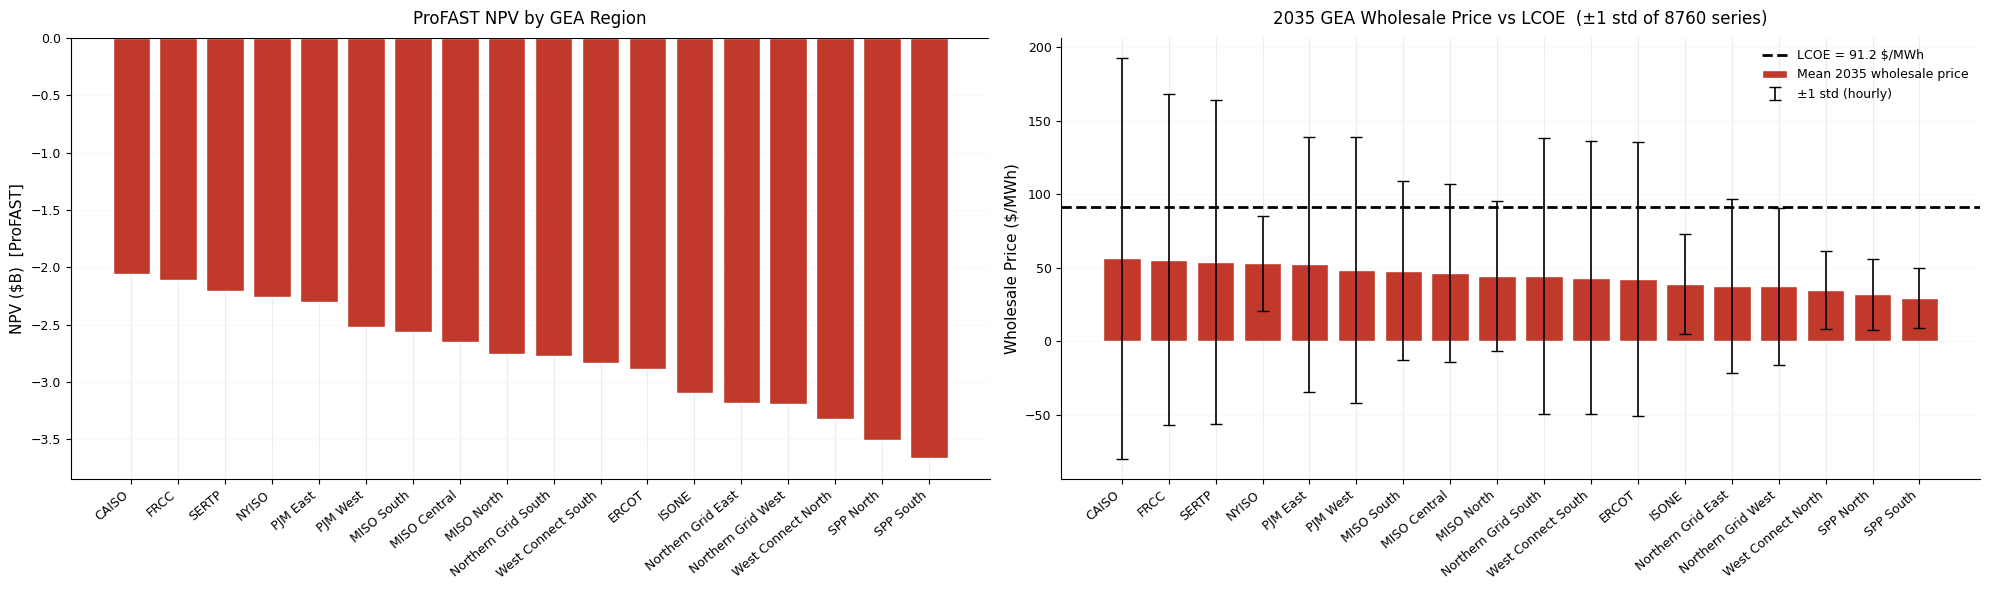


Saved: gea_region_npv.png  |  gea_region_npv_results.csv
Viable: 0 / 18 regions


In [34]:
pd.set_option('display.float_format', '{:.2f}'.format)
print(df[['gea_region','mean_price_$/MWh','min_price_$/MWh','max_price_$/MWh',
          'std_price_$/MWh','lcoe_$/MWh','spread_$/MWh','npv_$B','viable']].to_string(index=False))

# ── Bar chart ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))


x = range(len(df))
colors_npv   = ['#27ae60' if v else '#c0392b' for v in df['viable']]
colors_price = ['#27ae60' if p > LCOE_MWH else '#c0392b' for p in df['mean_price_$/MWh']]

ax = axes[0]
ax.bar(x, df['npv_$B'], color=colors_npv, edgecolor='white')
ax.axhline(0, color='black', lw=1.5)
ax.set_xticks(x)
ax.set_xticklabels(df['gea_region'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('NPV ($B)  [ProFAST]')
ax.set_title('ProFAST NPV by GEA Region')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x, df['mean_price_$/MWh'], color=colors_price, edgecolor='white',
       label='Mean 2035 wholesale price')
ax.errorbar(x, df['mean_price_$/MWh'],
            yerr=df['std_price_$/MWh'],
            fmt='none', color='black', capsize=4, lw=1.2, label='±1 std (hourly)')
ax.axhline(LCOE_MWH, color='black', lw=2, ls='--', label=f'LCOE = {LCOE_MWH:.1f} $/MWh')
ax.set_xticks(x)
ax.set_xticklabels(df['gea_region'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Wholesale Price ($/MWh)')
ax.set_title('2035 GEA Wholesale Price vs LCOE  (±1 std of 8760 series)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('gea_region_npv.png', dpi=150, bbox_inches='tight')
plt.show()

df.to_csv('gea_region_npv_results.csv', index=False)
print(f'\nSaved: gea_region_npv.png  |  gea_region_npv_results.csv')
print(f'Viable: {df["viable"].sum()} / {len(df)} regions')

## 5. Hourly Price Dynamics (8760 series)

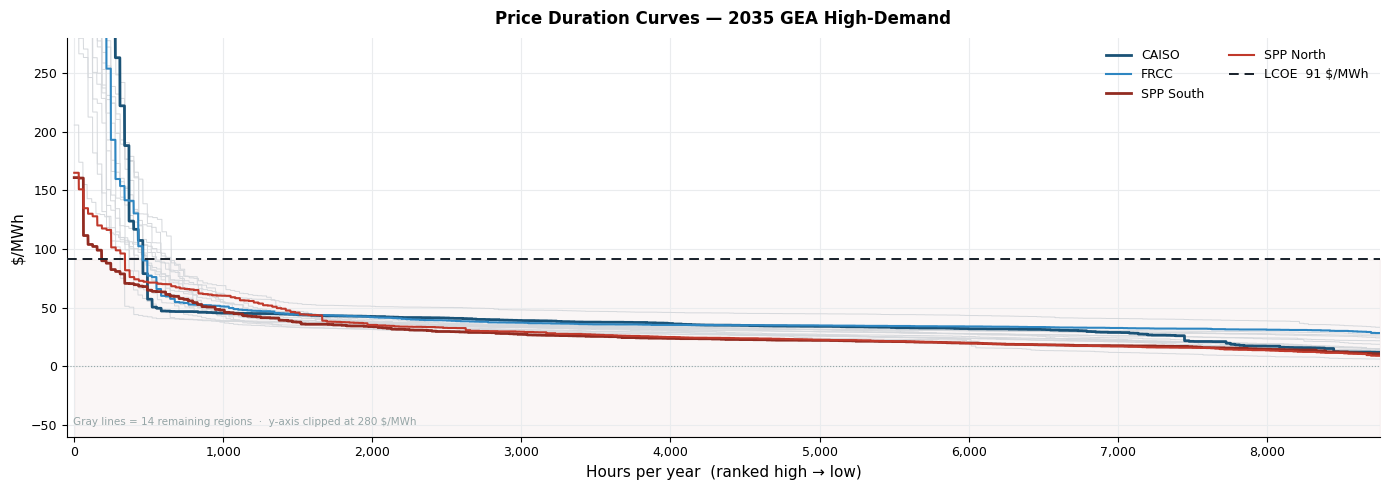

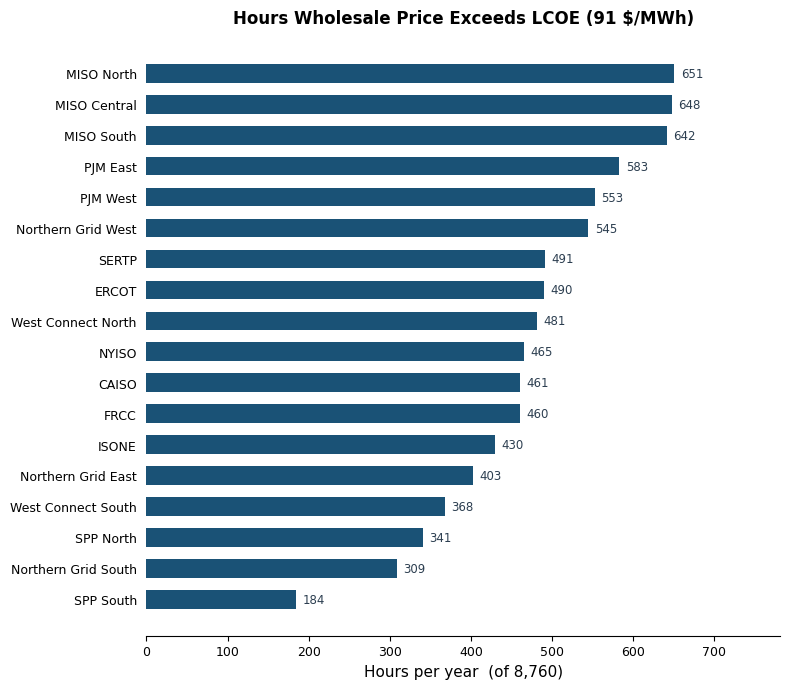

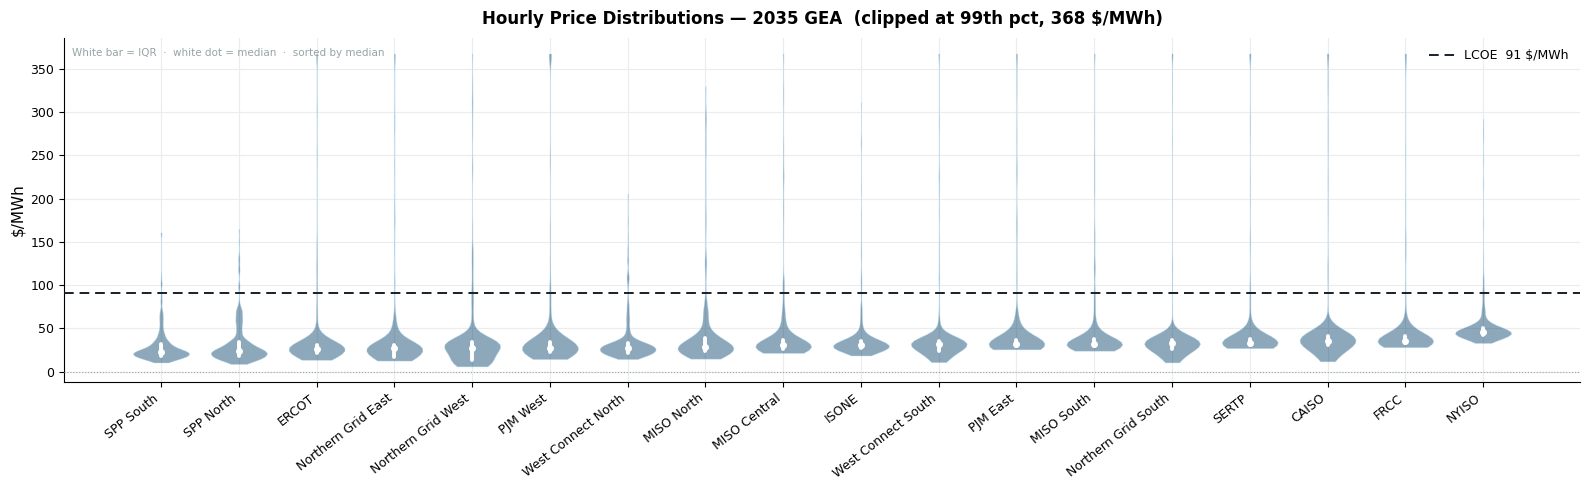

In [35]:
import matplotlib as mpl
import matplotlib.ticker as mticker

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcdefaults()
mpl.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#EAECEE',
    'grid.linestyle':    '-',
    'grid.linewidth':    0.8,
    'axes.axisbelow':    True,
    'axes.labelsize':    11,
    'axes.titlesize':    12,
    'axes.titlepad':     10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'legend.frameon':    False,
    'legend.fontsize':   9,
})

C_NEG  = '#922B21'
C_POS  = '#1A5276'
C_LCOE = '#17202A'
C_ZERO = '#95A5A6'
C_BG   = '#D5D8DC'

regions = sorted(gea_prices_mwh.keys())
means   = {r: float(np.mean(gea_prices_mwh[r])) for r in regions}

# ── Plot 3: Price Duration Curves ─────────────────────────────────────────────
ranked     = sorted(regions, key=lambda r: -means[r])
highlights = {
    ranked[0]:  ('#1A5276', 2.0),
    ranked[1]:  ('#2E86C1', 1.5),
    ranked[-1]: ('#922B21', 2.0),
    ranked[-2]: ('#C0392B', 1.5),
}

fig, ax = plt.subplots(figsize=(14, 5))

for r in regions:
    if r not in highlights:
        ax.plot(range(8760), np.sort(gea_prices_mwh[r])[::-1],
                color=C_BG, lw=0.7, zorder=1)

for r, (col, lw) in highlights.items():
    y_vals = np.sort(gea_prices_mwh[r])[::-1]
    ax.plot(range(8760), y_vals, color=col, lw=lw, zorder=3, label=r)

ax.fill_between(range(8760), -60, LCOE_MWH, color=C_NEG, alpha=0.04, zorder=0)
ax.axhline(LCOE_MWH, color=C_LCOE, lw=1.4, ls=(0, (5, 3)), zorder=4,
           label=f'LCOE  {LCOE_MWH:.0f} $/MWh')
ax.axhline(0, color=C_ZERO, lw=0.8, ls=':', zorder=2)

ax.set_xlim(-50, 8760)
ax.set_ylim(-60, 280)
ax.set_xlabel('Hours per year  (ranked high → low)')
ax.set_ylabel('$/MWh')
ax.set_title('Price Duration Curves — 2035 GEA High-Demand', fontweight='semibold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper right', ncol=2)
ax.text(0.005, 0.03, f'Gray lines = {len(regions)-4} remaining regions  ·  y-axis clipped at 280 $/MWh',
        transform=ax.transAxes, fontsize=7.5, color=C_ZERO)

plt.tight_layout()
plt.savefig('price_duration_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Plot 4: Hours Above LCOE ──────────────────────────────────────────────────
hours_above = {r: int(np.sum(gea_prices_mwh[r] > LCOE_MWH)) for r in regions}
df_above = (pd.DataFrame(list(hours_above.items()), columns=['gea_region', 'hours'])
            .sort_values('hours'))

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(range(len(df_above)), df_above['hours'],
        color=[C_POS if h > 0 else C_NEG for h in df_above['hours']],
        height=0.6, zorder=3)
for i, h in enumerate(df_above['hours']):
    ax.text(h + 8, i, f'{h:,}', va='center', fontsize=8.5, color='#2C3E50')

ax.set_yticks(range(len(df_above)))
ax.set_yticklabels(df_above['gea_region'])
ax.set_xlabel('Hours per year  (of 8,760)')
ax.set_title(f'Hours Wholesale Price Exceeds LCOE ({LCOE_MWH:.0f} $/MWh)', fontweight='semibold')
ax.set_xlim(0, df_above['hours'].max() * 1.2)
ax.grid(axis='x')
ax.grid(axis='y', visible=False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig('hours_above_lcoe.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Plot 5: Price Distributions (violin) ──────────────────────────────────────
order   = sorted(regions, key=lambda r: np.median(gea_prices_mwh[r]))
P99     = float(np.percentile(np.concatenate(list(gea_prices_mwh.values())), 99))
data    = [np.clip(gea_prices_mwh[r], None, P99) for r in order]

fig, ax = plt.subplots(figsize=(16, 5))
parts = ax.violinplot(data, positions=range(len(order)),
                      showmedians=False, showextrema=False, widths=0.72)

for pc in parts['bodies']:
    pc.set_facecolor(C_POS)
    pc.set_edgecolor('#AED6F1')
    pc.set_alpha(0.5)
    pc.set_linewidth(0.5)

for i, d in enumerate(data):
    q1, med, q3 = np.percentile(d, [25, 50, 75])
    ax.plot([i, i], [q1, q3], color='white', lw=2.8, solid_capstyle='round', zorder=4)
    ax.scatter(i, med, color='white', s=16, zorder=5)

ax.axhline(LCOE_MWH, color=C_LCOE, lw=1.4, ls=(0, (5, 3)), zorder=6,
           label=f'LCOE  {LCOE_MWH:.0f} $/MWh')
ax.axhline(0, color=C_ZERO, lw=0.8, ls=':', zorder=3)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=38, ha='right')
ax.set_ylabel('$/MWh')
ax.set_title(f'Hourly Price Distributions — 2035 GEA  (clipped at 99th pct, {P99:.0f} $/MWh)',
             fontweight='semibold')
ax.legend()
ax.text(0.005, 0.97, 'White bar = IQR  ·  white dot = median  ·  sorted by median',
        transform=ax.transAxes, fontsize=7.5, color=C_ZERO, va='top')

plt.tight_layout()
plt.savefig('price_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [1]:
1.150*1e3 * 8300*.3

2863500.0